# Proyecto de Análisis de Datos
## Análisis y Visualización de Datos de la Estación WIM Nobol
### Maestría en Ciencias de la Tierra

**Autor:**

Kevin Loor -Científico de datos

Carola Gordillo -Analista de Negocios

Ingrid Orta -Analista de datos

1. Conjunto de datos: wimDataNobol.csv
2. Entorno de trabajo
**Repositorio:** https://github.com/kevinloorf95-glitch/proyectoAD.git


## I. Introducción
Los sistemas WIM (Weigh-In-Motion) permiten medir el peso de los vehículos en movimiento sin necesidad de detenerlos. Esta información esfundamental para la planificación vial, diseño de pavimentos y control de sobrecargas.



## II. Objetivos

### Objetivo General
Realizar un análisis exploratorio y visualización de los datos de pesos de vehículos registrados mediante la estación WIM (Weigh-In-Motion) del MTOP en Nobol, Ecuador, para la identificación tendencias, patrones de carga y detección de posibles infracciones por sobrecarga.

### Objetivos Específicos
- Realizar la limpeza de los datos crudos de la estación WIM Nobol para el aumento de la precisión de los resultados.
- Realizar un análisis exploratorio de datos (EDA) mediante librerias de python, para el entendimiento de la distribución de las variables.
- Identificar los tipos de vehículos más comunes y sus patrones de carga mediante estaciones WIM para la detección de vehículos con exceso de peso y análisis de su proporción.
- Visualizar los resultados mediante gráficos estadísticos para mayor compresión de las variables.


## III. Descripción del Proyecto
Este proyecto utiliza los datos de la estación de pesaje en movimiento (WIM) ubicada en Nobol, provincia del Guayas, Ecuador, operada por el Ministerio de Transporte y Obras Públicas (MTOP). Los datos corresponden al período del 1 de mayo de 2015 al 8 de mayo de 2015 y contienen información detallada de cada vehículo pesado que transitó por la estación, incluyendo peso bruto, peso por eje, tipo de vehículo, número de ejes, y si cometió infracción por sobrecarga.

El análisis de espectros de carga es fundamental para el diseño empírico-mecanicista de pavimentos, permitiendo caracterizar el tránsito pesado y planificar la conservación de la red vial.

In [1]:
# ============================================================
# IMPORTAR LIBRERÍAS NECESARIAS
# numpy: operaciones numéricas y matriciales
# pandas: manipulación y análisis de datos estructurados
# matplotlib: creación de gráficos estáticos
# seaborn: visualización estadística basada en matplotlib
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo de gráficos
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('Librerías importadas correctamente.')

Librerías importadas correctamente.


## 3. CARGA DEL CONJUNTO DE DATOS

In [2]:
# ============================================================
# CARGA DEL CONJUNTO DE DATOS
# Cargamos el archivo CSV usando pandas con codificación utf-8-sig
# que maneja correctamente el BOM (Byte Order Mark) del archivo.
# ============================================================
ruta_csv = 'wimDataNobol.csv'
df = pd.read_csv(ruta_csv, encoding='utf-8-sig')

# Mostrar dimensiones y primeras filas del dataset
print('Dimensiones del dataset:', df.shape)
print('\nPrimeras 5 filas:')
df.head()

Dimensiones del dataset: (699697, 26)

Primeras 5 filas:


,AxlesCount,StartTimeStr,LaneNo,GrossWeight,Weight0,Weight1,Weight2,Weight3,Weight4,Weight5,...,StartTimeStr.1,Eje Sencillo (Ton),Eje Dual (Ton),Eje Tandem (Ton),Eje Tridem (Ton),Eje Tandem Posterior (Ton),Eje Dual Posterior (Ton),TOTAL TON,PESO MAX,EXCESO PESO
0,4.0,01/05/2015 00:00:10,1.0,11760.0,3730.0,4330.0,1720.0,1980.0,0.0,0.0,...,00:00:10,3.73,4.33,3.7,NaN,NaN,NaN,11.76,38.0,-
1,2.0,01/05/2015 00:01:22,1.0,3970.0,2030.0,1940.0,0.0,0.0,0.0,0.0,...,00:01:22,2.03,1.94,NaN,NaN,NaN,NaN,3.97,18.0,-
2,6.0,01/05/2015 00:02:18,1.0,22110.0,4190.0,4140.0,3980.0,3180.0,2910.0,3710.0,...,00:02:18,4.19,NaN,8.12,9.80,NaN,NaN,22.11,48.0,-
3,6.0,01/05/2015 00:02:41,1.0,20710.0,3950.0,4010.0,4500.0,2290.0,2670.0,3290.0,...,00:02:41,3.95,NaN,8.51,8.25,NaN,NaN,20.71,48.0,-
4,2.0,01/05/2015 00:03:25,2.0,10730.0,4970.0,5760.0,0.0,0.0,0.0,0.0,...,00:03:25,4.97,5.76,NaN,NaN,NaN,NaN,10.73,18.0,-


## 3.1 Limpieza inicial de datos

In [3]:
# ============================================================
# PREPROCESAMIENTO DE DATOS
# 1. Limpiar espacios en nombres de columnas
# 2. Convertir fechas a formato datetime
# 3. Extraer componentes temporales (hora, mes, etc.)
# 4. Convertir columna de exceso de peso a numérico
# 5. Verificar valores nulos y estadísticas básicas
# ============================================================

# 1. Limpiar nombres de columnas (eliminar espacios extra)
df.columns = df.columns.str.strip()
print('Nombres de columnas limpiados:')
print(list(df.columns))

# 2. Convertir StartTimeStr a formato datetime
df['StartTimeStr'] = pd.to_datetime(df['StartTimeStr'], format='%d/%m/%Y %H:%M:%S', errors='coerce')
# Eliminar columna duplicada de tiempo
if 'StartTimeStr.1' in df.columns:
    df.drop(columns=['StartTimeStr.1'], inplace=True)

# 3. Extraer componentes de fecha y hora para análisis temporal
df['Fecha'] = df['StartTimeStr'].dt.date
df['Hora'] = df['StartTimeStr'].dt.hour
df['Mes'] = df['StartTimeStr'].dt.month
df['Anio'] = df['StartTimeStr'].dt.year
df['DiaSemana'] = df['StartTimeStr'].dt.dayofweek  # 0=lunes, 6=domingo

# 4. Convertir EXCESO PESO a numérico (reemplazando guiones por 0)
df['EXCESO PESO'] = pd.to_numeric(df['EXCESO PESO'], errors='coerce').fillna(0)
# Crear columna booleana que indica si el vehículo tiene exceso de peso
df['TieneExceso'] = df['EXCESO PESO'] > 0

# 5. Verificar valores nulos por columna
print('\nValores nulos por columna:')
print(df.isnull().sum())

# 6. Estadísticas descriptivas básicas de todas las variables numéricas
print('\nEstadísticas descriptivas:')
df.describe()

Nombres de columnas limpiados:
['AxlesCount', 'StartTimeStr', 'LaneNo', 'GrossWeight', 'Weight0', 'Weight1', 'Weight2', 'Weight3', 'Weight4', 'Weight5', 'Weight6', 'Placa', 'Confiabilidad', 'tipo', 'infraccion', 'exce_peso', 'StartTimeStr.1', 'Eje Sencillo (Ton)', 'Eje Dual (Ton)', 'Eje Tandem (Ton)', 'Eje Tridem (Ton)', 'Eje Tandem Posterior (Ton)', 'Eje Dual Posterior (Ton)', 'TOTAL TON', 'PESO MAX', 'EXCESO PESO']

Valores nulos por columna:
AxlesCount                     16714
StartTimeStr                   16714
LaneNo                         16714
GrossWeight                    16714
Weight0                        16714
Weight1                        16714
Weight2                        16714
Weight3                        16714
Weight4                        16714
Weight5                        16714
Weight6                        16714
Placa                          16714
Confiabilidad                  16714
tipo                           16714
infraccion                     16

,AxlesCount,StartTimeStr,LaneNo,GrossWeight,Weight0,Weight1,Weight2,Weight3,Weight4,Weight5,...,Eje Sencillo (Ton),Eje Tridem (Ton),Eje Tandem Posterior (Ton),TOTAL TON,PESO MAX,EXCESO PESO,Hora,Mes,Anio,DiaSemana
count,682983.000000,682983,682983.000000,682983.000000,682983.000000,682983.000000,682983.000000,682983.000000,682983.000000,682983.000000,...,682983.000000,96912.000000,282.000000,682983.000000,682983.000000,699697.000000,682983.000000,682983.000000,682983.000000,682983.000000
mean,2.787591,2015-10-27 21:35:48.064460,1.076154,18634.235933,4743.596371,7931.384032,2630.977960,1196.766230,1061.012412,1070.498929,...,4.743596,22.150519,14.809894,18.634236,24.336350,0.768762,12.236234,6.583165,2015.316673,2.762987
min,2.000000,2015-05-01 00:00:10,1.000000,200.000000,100.000000,100.000000,0.000000,0.000000,0.000000,0.000000,...,0.100000,0.240000,0.730000,0.200000,18.000000,0.000000,0.000000,1.000000,2015.000000,0.000000
25%,2.000000,2015-07-31 15:36:20.500000,1.000000,9090.000000,3500.000000,4660.000000,0.000000,0.000000,0.000000,0.000000,...,3.500000,18.940000,8.660000,9.090000,18.000000,0.000000,8.000000,4.000000,2015.000000,1.000000
50%,2.000000,2015-10-28 09:41:29,1.000000,13830.000000,4850.000000,7570.000000,0.000000,0.000000,0.000000,0.000000,...,4.850000,23.650000,15.310000,13.830000,18.000000,0.000000,12.000000,7.000000,2015.000000,3.000000
75%,3.000000,2016-01-28 14:55:57.500000,1.000000,22600.000000,5900.000000,10390.000000,3920.000000,0.000000,0.000000,0.000000,...,5.900000,26.410000,21.197500,22.600000,27.000000,0.000000,17.000000,10.000000,2016.000000,4.000000
max,6.000000,2016-04-30 23:52:44,2.000000,74970.000000,51390.000000,52670.000000,50870.000000,37220.000000,43840.000000,19800.000000,...,51.390000,68.790000,35.330000,74.970000,48.000000,55.200000,23.000000,12.000000,2016.000000,6.000000
std,1.393560,NaN,0.265245,13857.856963,1654.930036,3966.386569,4415.412739,2770.274251,2758.380107,2828.709665,...,1.654930,6.725029,6.818925,13.857857,10.734205,2.189899,5.595060,3.445048,0.465179,1.879795


In [4]:
# ============================================================
# FUNCIONES PARA AUTOMATIZAR TAREAS DE LIMPIEZA
# Creamos funciones reutilizables para:
# - Limpiar nombres de columnas
# - Tratar valores nulos con diferentes estrategias
# - Clasificar turnos según la hora del día
# ============================================================

def limpiar_nombres_columnas(df):
    '''Elimina espacios extra y estandariza nombres de columnas'''
    df.columns = df.columns.str.strip().str.replace('(', '', regex=False).str.replace(')', '', regex=False).str.replace(' ', '_', regex=False)
    return df

def tratar_valores_nulos(df, columna, estrategia='cero'):
    '''Llena valores nulos según una estrategia: cero, media, mediana'''
    if estrategia == 'cero':
        df[columna] = df[columna].fillna(0)
    elif estrategia == 'media':
        df[columna] = df[columna].fillna(df[columna].mean())
    elif estrategia == 'mediana':
        df[columna] = df[columna].fillna(df[columna].median())
    return df

def clasificar_turno(hora):
    '''Clasifica la hora en turno: madrugada, mañana, tarde, noche'''
    if pd.isna(hora):
        return 'Desconocido'
    elif 0 <= hora < 6:
        return 'Madrugada'
    elif 6 <= hora < 12:
        return 'Mañana'
    elif 12 <= hora < 18:
        return 'Tarde'
    else:
        return 'Noche'

# Aplicar las funciones creadas
df_clean = limpiar_nombres_columnas(df.copy())
# Convertir columnas de ejes a numérico (algunas vienen como object por valores '-   ')
columnas_ejes = ['Eje_Sencillo_Ton', 'Eje_Dual_Ton', 'Eje_Tandem_Ton',
                 'Eje_Tridem_Ton', 'Eje_Tandem_Posterior_Ton', 'Eje_Dual_Posterior_Ton']
for col in columnas_ejes:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

df_clean['Turno'] = df_clean['Hora'].apply(clasificar_turno)

print('Funciones de limpieza creadas y aplicadas correctamente.')
print('\nDistribución de vehículos por turno:')
print(df_clean['Turno'].value_counts())

Funciones de limpieza creadas y aplicadas correctamente.

Distribución de vehículos por turno:
Turno
Tarde          239686
Mañana         216230
Noche          137185
Madrugada       89882
Desconocido     16714
Name: count, dtype: int64


## IV. Metodología utilizada para el análisis de datos

### Fuente de datos
Los datos provienen de la estación WIM (Weigh-In-Motion) del MTOP ubicada en Nobol, provincia del Guayas, Ecuador. El período de recolección abarca del 1 de mayo de 2015 al 30 de abril de 2016.

### Proceso de análisis
1. **Carga de datos:** Importación del archivo CSV utilizando la librería pandas.
2. **Limpieza y preprocesamiento:** Corrección de tipos de datos, eliminación de espacios en nombres de columnas, tratamiento de valores nulos, conversión de fechas, y creación de nuevas columnas derivadas para facilitar el análisis.
3. **Análisis exploratorio (EDA):** Cálculo de estadísticas descriptivas, detección de valores atípicos (outliers), análisis de distribución de variables numéricas y categóricas.
4. **Visualización:** Generación de gráficos de histogramas, diagramas de caja, series temporales, mapas de calor, y gráficos de barras utilizando matplotlib y seaborn.
5. **Interpretación:** Análisis de resultados y formulación de conclusiones y recomendaciones basadas en los hallazgos.

### Herramientas Utilizadas
- **Python 3** con las librerías: numpy, pandas, matplotlib, seaborn.
- **Jupyter Notebook** como entorno de desarrollo interactivo.
- **GitHub** para el control de versiones y almacenamiento del proyecto.

## 4. ANÁLISIS EXPLORATORIO DE DATOS (EDA)

In [5]:
# ============================================================
# ANÁLISIS EXPLORATORIO DE DATOS (EDA)
    # Estadísticas descriptivas de las variables numéricas principales
# GrossWeight: peso bruto del vehículo en kg
# Weight0-Weight6: peso de cada eje individual
# TOTAL_TON: peso total en toneladas
# PESO_MAX: peso máximo permitido
# EXCESO_PESO: cantidad de exceso de peso
# ============================================================

variables_num = ['GrossWeight', 'Weight0', 'Weight1', 'TOTAL_TON', 'PESO_MAX', 'EXCESO_PESO']
print('Estadísticas descriptivas de variables numéricas principales:')
df_clean[variables_num].describe()

Estadísticas descriptivas de variables numéricas principales:


,GrossWeight,Weight0,Weight1,TOTAL_TON,PESO_MAX,EXCESO_PESO
count,682983.000000,682983.000000,682983.000000,682983.000000,682983.000000,699697.000000
mean,18634.235933,4743.596371,7931.384032,18.634236,24.336350,0.768762
std,13857.856963,1654.930036,3966.386569,13.857857,10.734205,2.189899
min,200.000000,100.000000,100.000000,0.200000,18.000000,0.000000
25%,9090.000000,3500.000000,4660.000000,9.090000,18.000000,0.000000
50%,13830.000000,4850.000000,7570.000000,13.830000,18.000000,0.000000
75%,22600.000000,5900.000000,10390.000000,22.600000,27.000000,0.000000
max,74970.000000,51390.000000,52670.000000,74.970000,48.000000,55.200000


In [6]:
# ============================================================
# DETECCIÓN DE OUTLIERS (VALORES ATÍPICOS)
# Usamos el método del rango intercuartil (IQR) para identificar
# valores atípicos en GrossWeight y TOTAL_TON.
# Un outlier es un valor que está fuera de 1.5*IQR por debajo de Q1
# o por encima de Q3.
# ============================================================

def detectar_outliers_iqr(df, columna):
    '''Detecta outliers usando el método del rango intercuartil (IQR)'''
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    outliers = df[(df[columna] < limite_inferior) | (df[columna] > limite_superior)]
    print(f'{columna}:')
    print(f'  Q1 = {Q1:.2f}, Q3 = {Q3:.2f}, IQR = {IQR:.2f}')
    print(f'  Limite inferior = {limite_inferior:.2f}, Limite superior = {limite_superior:.2f}')
    print(f'  Cantidad de outliers = {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)')
    print()
    return outliers

# Detectar outliers en peso bruto y peso total
outliers_gw = detectar_outliers_iqr(df_clean, 'GrossWeight')
outliers_tt = detectar_outliers_iqr(df_clean, 'TOTAL_TON')

print(f'Total de registros con exceso de peso: {df_clean["TieneExceso"].sum()}')
print(f'Porcentaje con exceso de peso: {df_clean["TieneExceso"].mean()*100:.2f}%')

GrossWeight:
  Q1 = 9090.00, Q3 = 22600.00, IQR = 13510.00
  Limite inferior = -11175.00, Limite superior = 42865.00
  Cantidad de outliers = 69180 (9.89%)

TOTAL_TON:
  Q1 = 9.09, Q3 = 22.60, IQR = 13.51
  Limite inferior = -11.18, Limite superior = 42.87
  Cantidad de outliers = 69180 (9.89%)

Total de registros con exceso de peso: 131926
Porcentaje con exceso de peso: 18.85%


In [7]:
# ============================================================
# ANÁLISIS POR TIPO DE VEHÍCULO
# Agrupamos los datos por tipo de vehículo (columna 'tipo')
# y calculamos estadísticas: conteo, media, mediana, etc.
# ============================================================

print('Distribución de tipos de vehículo:')
print(df_clean['tipo'].value_counts())
print()

# Agrupar por tipo y calcular estadísticas agregadas
agrupado_tipo = df_clean.groupby('tipo').agg({
    'GrossWeight': ['count', 'mean', 'median', 'std'],
    'TOTAL_TON': ['mean', 'max'],
    'TieneExceso': 'sum'
}).round(2)

print('Estadísticas por tipo de vehículo:')
agrupado_tipo

Distribución de tipos de vehículo:
tipo
2DB    463612
3S3     95158
3A      91144
2S2     27110
2S1      2039
3S1      1884
2S3      1754
3S2       282
Name: count, dtype: int64

Estadísticas por tipo de vehículo:


GrossWeight                              TOTAL_TON        TieneExceso
           count      mean   median       std      mean    max         sum
tipo                                                                      
2DB       463612  11965.05  11750.0   5174.99     11.97  74.10       49537
2S1         2039   8809.10   5680.0   9963.59      8.81  74.24          92
2S2        27110  21089.41  18335.0   8774.00     21.09  64.69        1001
2S3         1754  29669.38  30900.0  13074.11     29.67  68.12         258
3A         91144  23301.45  26350.0  10572.48     23.30  53.18       39099
3S1         1884  21876.52  25250.0  12132.81     21.88  53.31           7
3S2          282  34016.10  33310.0  14469.70     34.02  67.90          46
3S3        95158  45854.22  49350.0  11164.11     45.85  74.97       41886

In [8]:
# ============================================================
# ANÁLISIS TEMPORAL BÁSICO
# Analizamos la distribución del tráfico por hora del día,
# por mes, y por turno (madrugada, mañana, tarde, noche).
# También analizamos el exceso de peso por turno.
# ============================================================

# Tráfico por hora del día
trafico_hora = df_clean.groupby('Hora').size()
print('Tráfico por hora del día:')
print(trafico_hora)

print('\nTráfico por mes:')
trafico_mes = df_clean.groupby('Mes').size()
print(trafico_mes)

print('\nExceso de peso por turno:')
exceso_turno = df_clean.groupby('Turno')['TieneExceso'].agg(['count', 'sum'])
exceso_turno['porcentaje'] = (exceso_turno['sum'] / exceso_turno['count'] * 100).round(2)
print(exceso_turno)

Tráfico por hora del día:
Hora
0.0      9887
1.0      8951
2.0      9600
3.0     13391
4.0     20048
5.0     28005
6.0     33246
7.0     33607
8.0     33860
9.0     35726
10.0    39848
11.0    39943
12.0    39513
13.0    39751
14.0    41083
15.0    41484
16.0    40517
17.0    37338
18.0    33953
19.0    30560
20.0    25242
21.0    19790
22.0    15696
23.0    11944
dtype: int64

Tráfico por mes:
Mes
1.0     50921
2.0     50360
3.0     63612
4.0     51389
5.0     92304
6.0     22423
7.0     56740
8.0     57373
9.0     60243
10.0    60335
11.0    56998
12.0    60285
dtype: int64

Exceso de peso por turno:
              count    sum  porcentaje
Turno                                 
Desconocido   16714      0        0.00
Madrugada     89882  12514       13.92
Mañana       216230  43589       20.16
Noche        137185  23048       16.80
Tarde        239686  52775       22.02


## V. Resultados Principales
### 5. Visualización de datos
### Distribución de Variables Numéricas
A continuación se presentan histogramas que muestran la distribución de las principales variables numéricas del dataset.

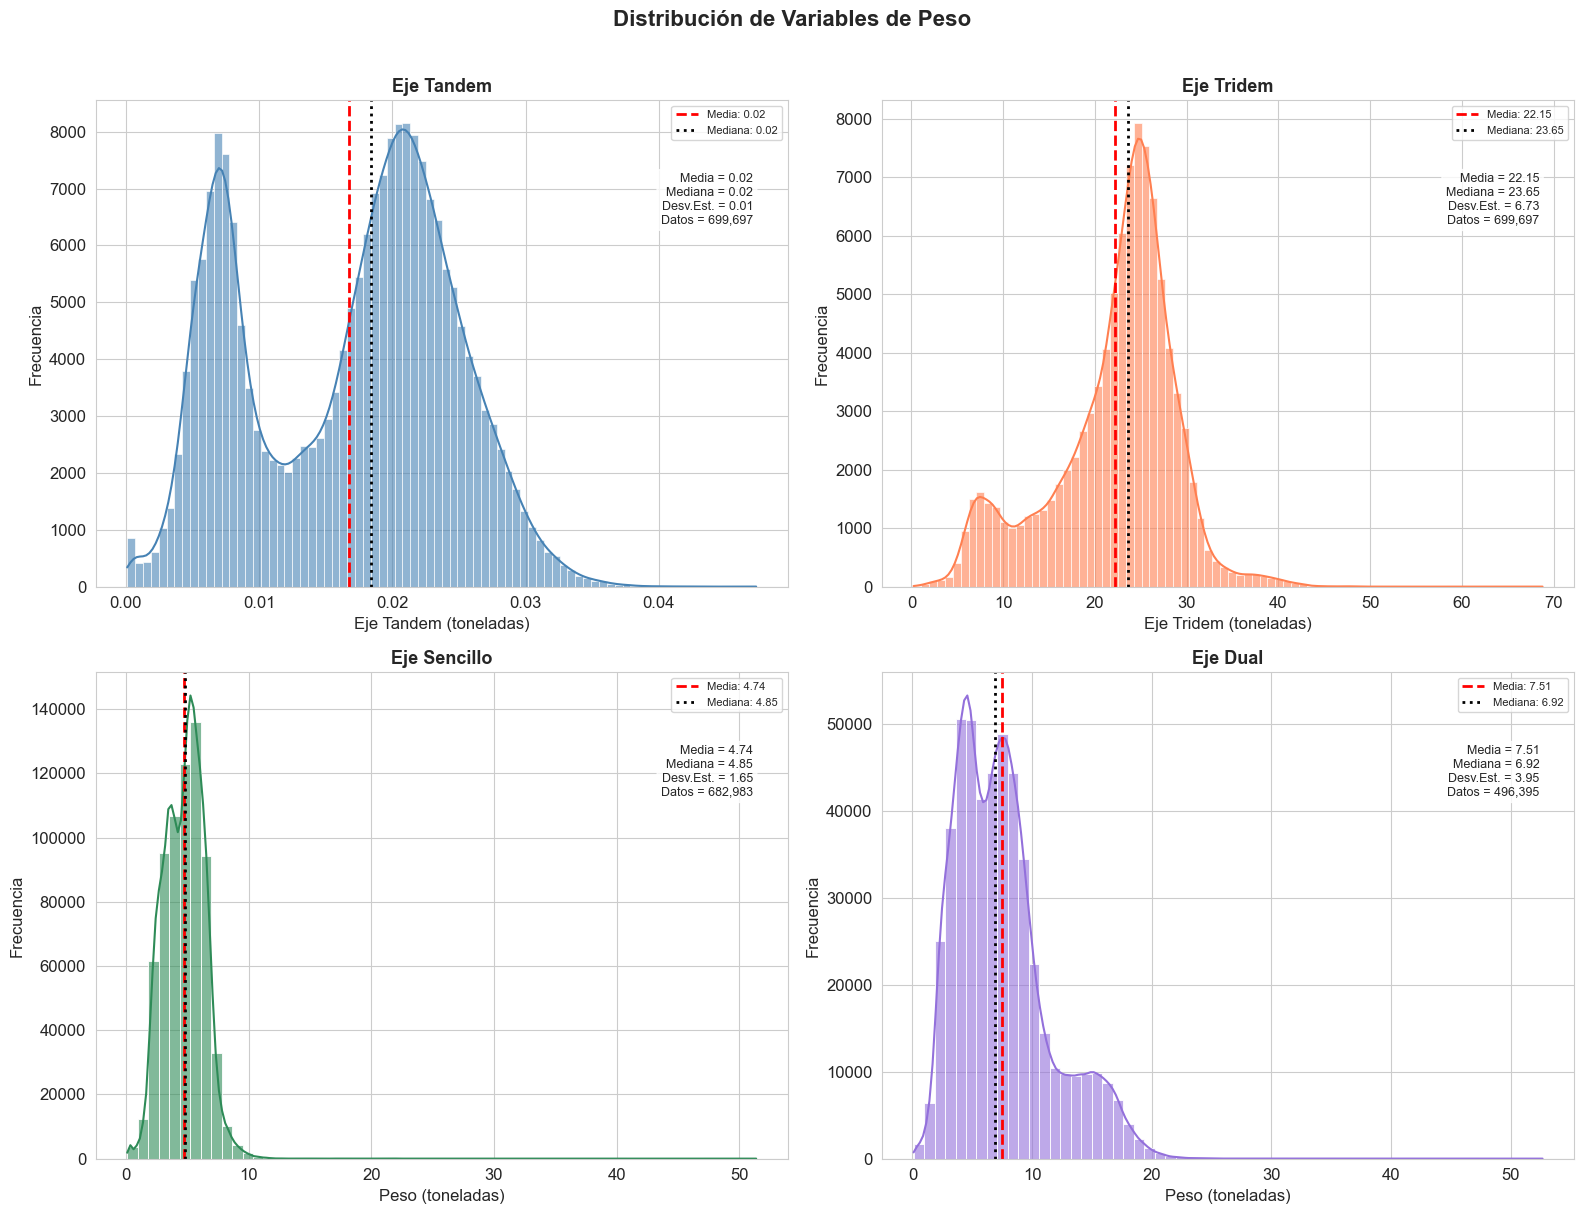

In [9]:
# ============================================================
# HISTOGRAMAS CON CURVA KDE DE DISTRIBUCIÓN DE PESOS
# Mejoramos los histogramas básicos añadiendo:
# - Curva KDE (Kernel Density Estimate) para ver la forma
#   suavizada de la distribución
# - Líneas verticales para media y mediana
# - Notas estadísticas (media, mediana, desviación)
# - Usamos seaborn (histplot) que integra KDE automáticamente
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Distribución de Variables de Peso', fontsize=16, fontweight='bold', y=1.01)

# Configuración común: histograma + KDE con seaborn
configs = [
    {
        'data': df_clean['Eje_Tandem_Ton'] / 1000,
        'ax': axes[0, 0],
        'title': 'Eje Tandem',
        'xlabel': 'Eje Tandem (toneladas)',
        'color': 'steelblue',
        'bins': 80
    },
    {
        'data': df_clean['Eje_Tridem_Ton'],
        'ax': axes[0, 1],
        'title': 'Eje Tridem',
        'xlabel': 'Eje Tridem (toneladas)',
        'color': 'coral',
        'bins': 80
    },
    {
        'data': df_clean['Eje_Sencillo_Ton'].dropna(),
        'ax': axes[1, 0],
        'title': 'Eje Sencillo',
        'xlabel': 'Peso (toneladas)',
        'color': 'seagreen',
        'bins': 60
    },
    {
        'data': df_clean['Eje_Dual_Ton'].dropna(),
        'ax': axes[1, 1],
        'title': 'Eje Dual',
        'xlabel': 'Peso (toneladas)',
        'color': 'mediumpurple',
        'bins': 60
    }
]

for cfg in configs:
    data = cfg['data']
    ax = cfg['ax']
    media = data.mean()
    mediana = data.median()
    std = data.std()

    # Histograma con curva KDE
    sns.histplot(data, bins=cfg['bins'], color=cfg['color'],
                 edgecolor='white', alpha=0.6, kde=True, ax=ax)

    # Línea vertical para la media (rojo) y mediana (negra)
    ax.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.2f}')
    ax.axvline(mediana, color='black', linestyle=':', linewidth=2, label=f'Mediana: {mediana:.2f}')

    # Anotación con estadísticas
    ax.text(0.95, 0.85, f'Media = {media:.2f}\nMediana = {mediana:.2f}\nDesv.Est. = {std:.2f}\nDatos = {len(data):,}',
            transform=ax.transAxes, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), fontsize=9)

    ax.set_title(cfg['title'], fontsize=13, fontweight='bold')
    ax.set_xlabel(cfg['xlabel'])
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

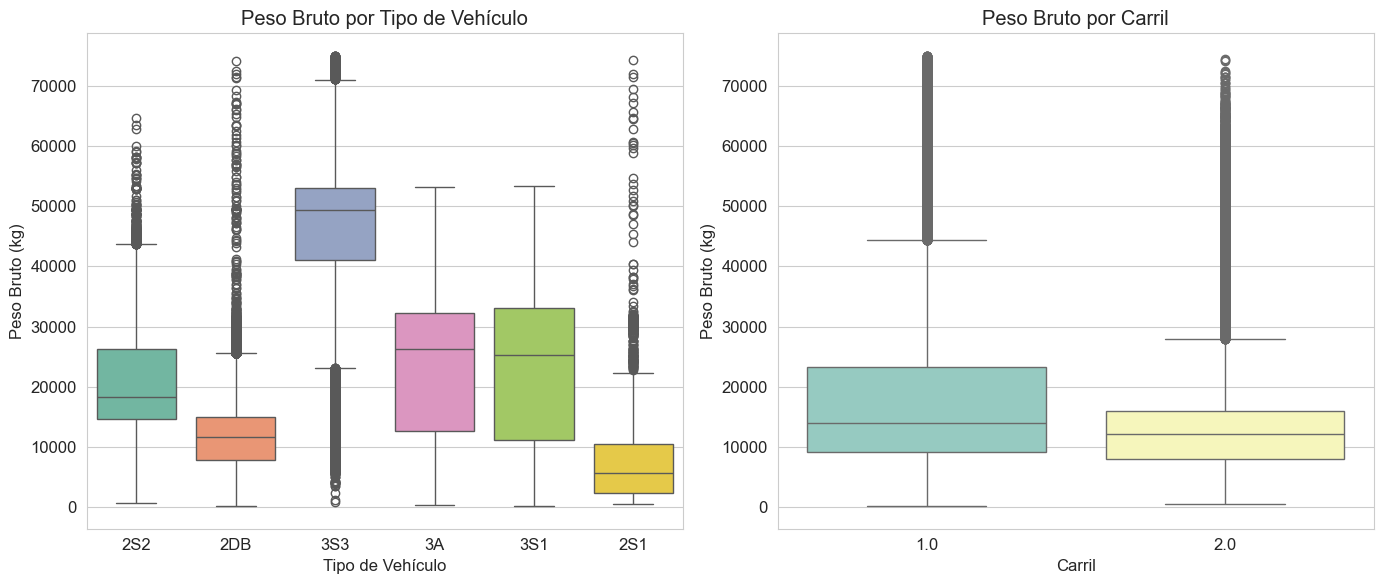

In [10]:
# ============================================================
# DIAGRAMAS DE CAJA Y BIGOTE (BOX PLOTS)
# Los box plots muestran la mediana, cuartiles y outliers
# de una variable. Comparamos peso bruto por tipo de vehículo
# y por carril.
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Box plot de peso bruto por tipo de vehículo (top 6 tipos más comunes)
top_tipos = df_clean['tipo'].value_counts().head(6).index
df_top = df_clean[df_clean['tipo'].isin(top_tipos)]

sns.boxplot(data=df_top, x='tipo', y='GrossWeight', ax=axes[0], palette='Set2')
axes[0].set_title('Peso Bruto por Tipo de Vehículo')
axes[0].set_xlabel('Tipo de Vehículo')
axes[0].set_ylabel('Peso Bruto (kg)')

# Box plot de peso bruto por carril (LaneNo)
sns.boxplot(data=df_clean, x='LaneNo', y='GrossWeight', ax=axes[1], palette='Set3')
axes[1].set_title('Peso Bruto por Carril')
axes[1].set_xlabel('Carril')
axes[1].set_ylabel('Peso Bruto (kg)')

plt.tight_layout()
plt.show()

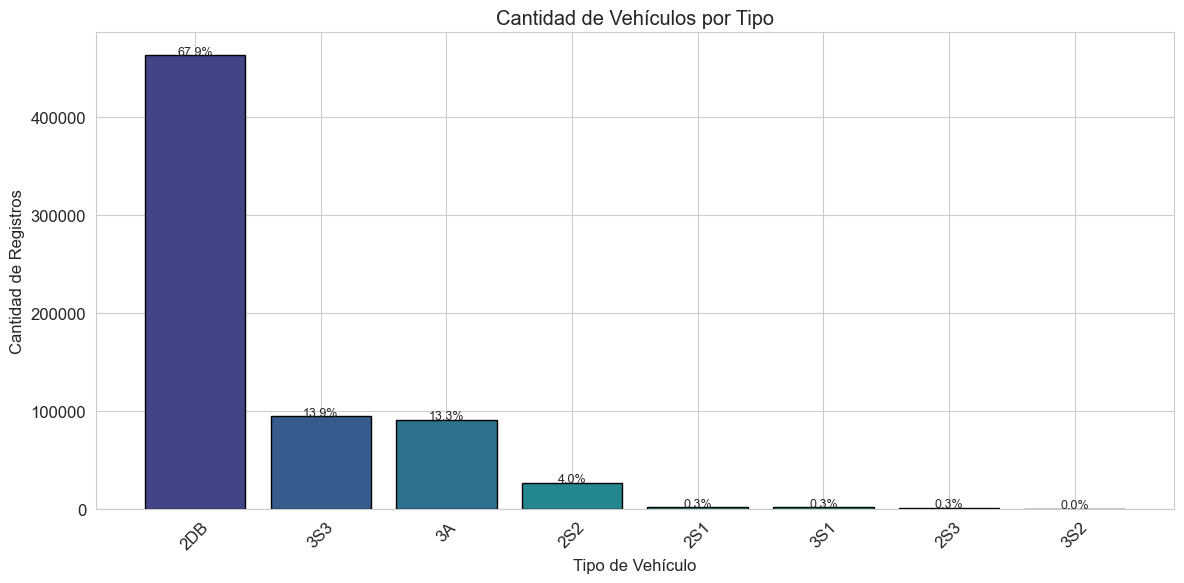

Total de vehículos pesados registrados: 682,983


In [11]:
# ============================================================
# GRÁFICO DE BARRAS - VEHÍCULOS POR TIPO
# Mostramos la cantidad de vehículos registrados por cada
# tipo de configuración vehicular (2DB, 3S3, 2S2, etc.)
# con etiquetas de porcentaje sobre cada barra.
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

conteo_tipos = df_clean['tipo'].value_counts()
colores = plt.cm.viridis(np.linspace(0.2, 0.8, len(conteo_tipos)))

ax.bar(conteo_tipos.index, conteo_tipos.values, color=colores, edgecolor='black')
ax.set_title('Cantidad de Vehículos por Tipo')
ax.set_xlabel('Tipo de Vehículo')
ax.set_ylabel('Cantidad de Registros')
ax.tick_params(axis='x', rotation=45)

# Agregar etiquetas de porcentaje sobre cada barra
total = conteo_tipos.sum()
for i, v in enumerate(conteo_tipos.values):
    pct = v / total * 100
    ax.text(i, v + 500, f'{pct:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f'Total de vehículos pesados registrados: {total:,}')

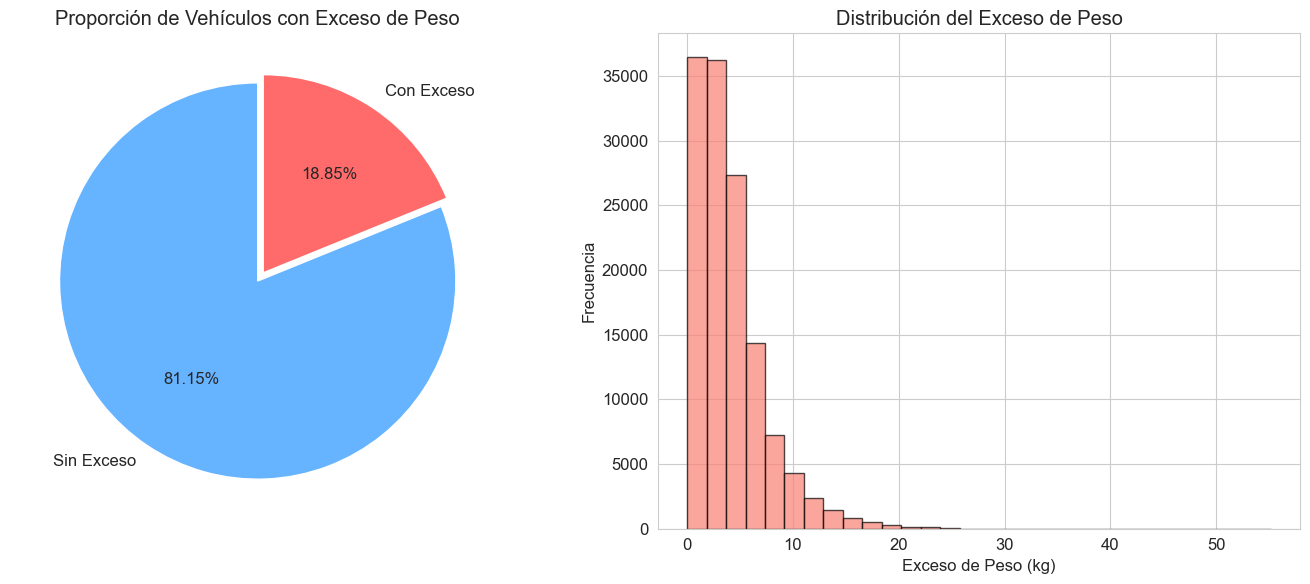

Vehículos con exceso: 131926 (18.85%)
Vehículos sin exceso: 567771 (81.15%)

Exceso promedio: 4.08 kg
Exceso máximo: 55.20 kg


In [12]:
# ============================================================
# ANÁLISIS DE EXCESO DE PESO
# Gráfico de pastel que muestra la proporción de vehículos
# con y sin exceso de peso, e histograma de la magnitud
# del exceso para los vehículos infractores.
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de pastel: proporción de vehículos con/sin exceso
exceso_counts = df_clean['TieneExceso'].value_counts()
labels = ['Sin Exceso', 'Con Exceso']
colors = ['#66b3ff', '#ff6b6b']

axes[0].pie(exceso_counts.values, labels=labels, autopct='%1.2f%%',
            colors=colors, startangle=90, explode=(0, 0.05))
axes[0].set_title('Proporción de Vehículos con Exceso de Peso')

# Histograma de la magnitud del exceso de peso
df_exceso = df_clean[df_clean['TieneExceso'] == True]
if len(df_exceso) > 0:
    axes[1].hist(df_exceso['EXCESO_PESO'], bins=30, color='salmon', edgecolor='black', alpha=0.7)
    axes[1].set_title('Distribución del Exceso de Peso')
    axes[1].set_xlabel('Exceso de Peso (kg)')
    axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print(f'Vehículos con exceso: {exceso_counts.get(True, 0)} ({exceso_counts.get(True, 0)/len(df_clean)*100:.2f}%)')
print(f'Vehículos sin exceso: {exceso_counts.get(False, 0)} ({exceso_counts.get(False, 0)/len(df_clean)*100:.2f}%)')

if len(df_exceso) > 0:
    print(f'\nExceso promedio: {df_exceso["EXCESO_PESO"].mean():.2f} kg')
    print(f'Exceso máximo: {df_exceso["EXCESO_PESO"].max():.2f} kg')

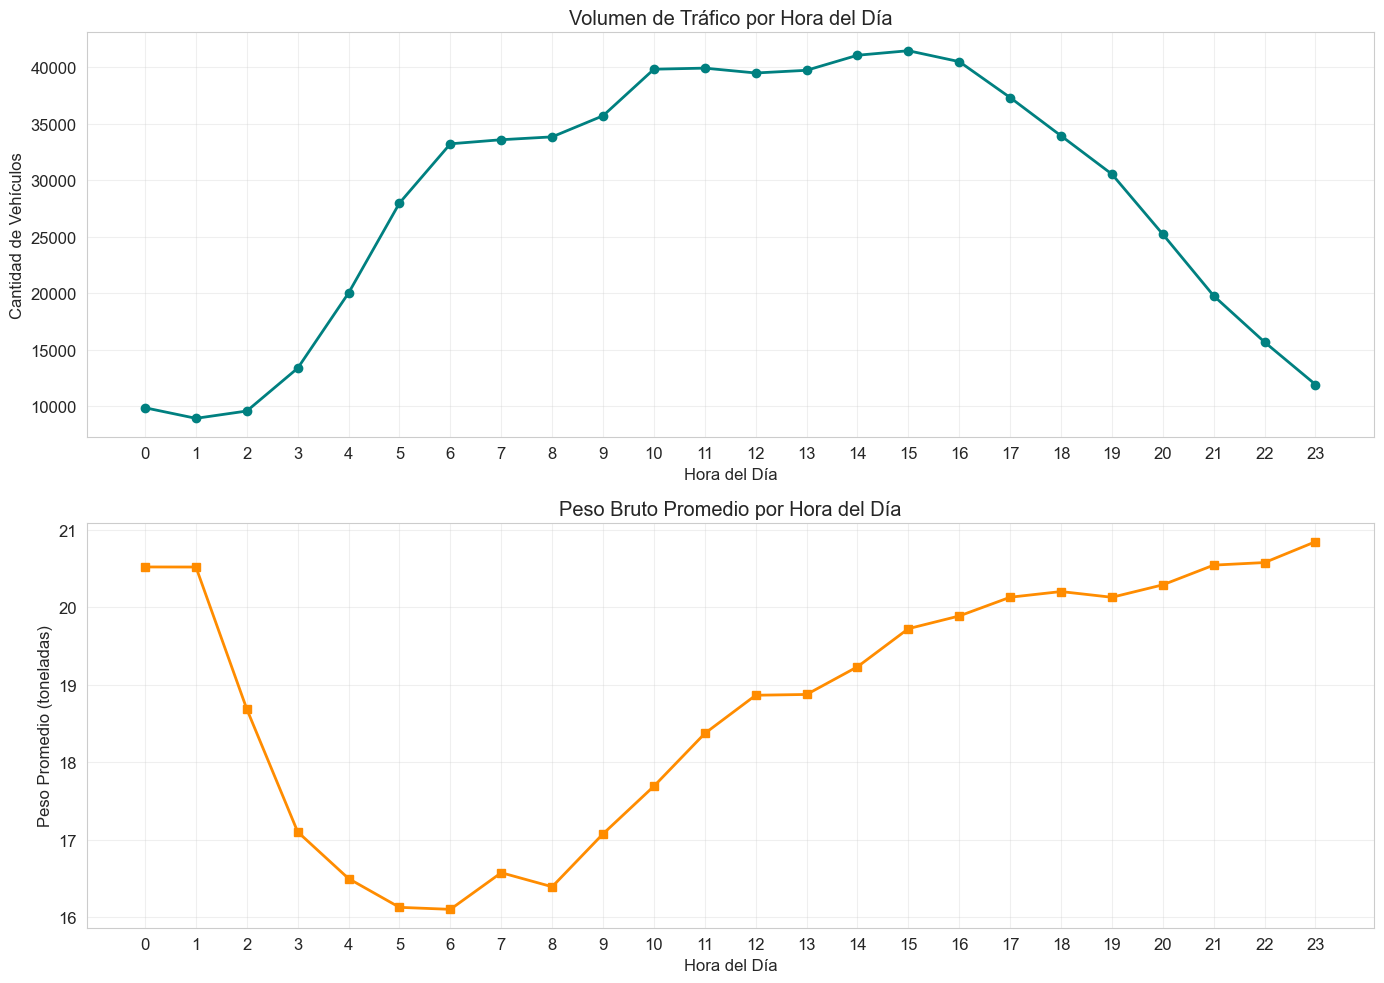

In [13]:
# ============================================================
# GRÁFICO DE LÍNEAS - TENDENCIA TEMPORAL
# Analizamos el volumen de tráfico y el peso promedio por
# hora del día para identificar patrones temporales.
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Volumen de tráfico por hora del día
trafico_hora = df_clean.groupby('Hora').size()
axes[0].plot(trafico_hora.index, trafico_hora.values, marker='o', linestyle='-',
             color='teal', linewidth=2, markersize=6)
axes[0].set_title('Volumen de Tráfico por Hora del Día')
axes[0].set_xlabel('Hora del Día')
axes[0].set_ylabel('Cantidad de Vehículos')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(0, 24))

# Peso bruto promedio por hora del día
peso_prom_hora = df_clean.groupby('Hora')['GrossWeight'].mean() / 1000
axes[1].plot(peso_prom_hora.index, peso_prom_hora.values, marker='s', linestyle='-',
             color='darkorange', linewidth=2, markersize=6)
axes[1].set_title('Peso Bruto Promedio por Hora del Día')
axes[1].set_xlabel('Hora del Día')
axes[1].set_ylabel('Peso Promedio (toneladas)')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

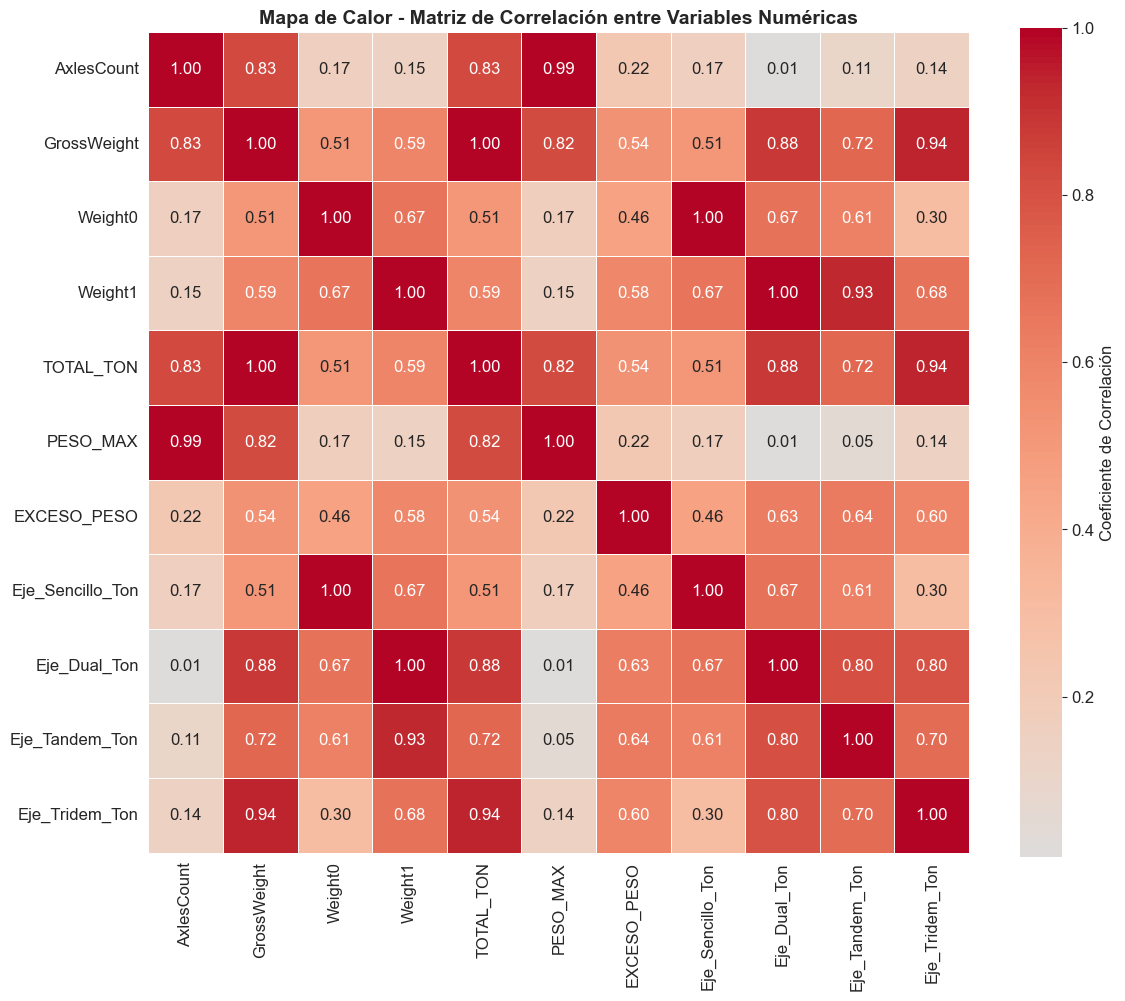

Principales correlaciones:
GrossWeight vs TOTAL_TON: 1.0000


In [14]:
# ============================================================
# MAPA DE CALOR - MATRIZ DE CORRELACIÓN
# Un mapa de calor que visualiza las correlaciones entre
# variables numéricas. Colores rojos = correlación positiva,
# azules = correlación negativa, blanco = sin correlación.
# ============================================================

# Seleccionar columnas numéricas para la correlación
cols_correlacion = ['AxlesCount', 'GrossWeight', 'Weight0', 'Weight1',
                    'TOTAL_TON', 'PESO_MAX', 'EXCESO_PESO',
                    'Eje_Sencillo_Ton', 'Eje_Dual_Ton', 'Eje_Tandem_Ton', 'Eje_Tridem_Ton']

# Filtrar solo columnas que existen en el dataframe
cols_existentes = [c for c in cols_correlacion if c in df_clean.columns]
matriz_corr = df_clean[cols_existentes].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', linewidths=0.5, square=True,
            cbar_kws={'label': 'Coeficiente de Correlación'})
plt.title('Mapa de Calor - Matriz de Correlación entre Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Principales correlaciones:')
corr_gw_tt = df_clean['GrossWeight'].corr(df_clean['TOTAL_TON'])
print(f'GrossWeight vs TOTAL_TON: {corr_gw_tt:.4f}')

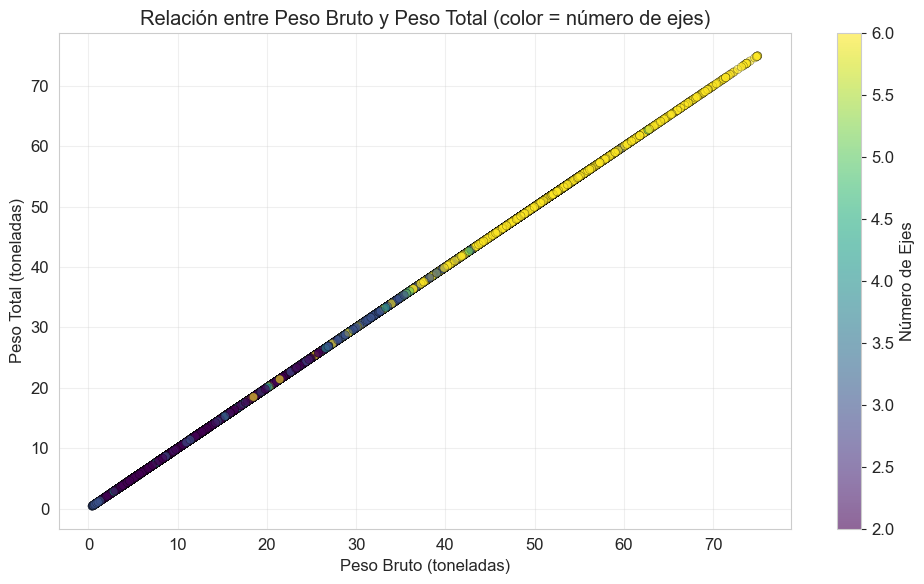

In [15]:
# ============================================================
# GRÁFICO DE DISPERSIÓN
# Relación entre peso bruto y peso total, coloreado por
# número de ejes. Usamos una muestra del 10% para evitar
# saturación del gráfico.
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

# Tomar una muestra aleatoria del 10% de los datos
df_muestra = df_clean.sample(frac=0.1, random_state=42)

scatter = ax.scatter(df_muestra['GrossWeight'] / 1000, df_muestra['TOTAL_TON'],
                     c=df_muestra['AxlesCount'], cmap='viridis', alpha=0.6,
                     edgecolors='black', linewidth=0.3)
ax.set_title('Relación entre Peso Bruto y Peso Total (color = número de ejes)')
ax.set_xlabel('Peso Bruto (toneladas)')
ax.set_ylabel('Peso Total (toneladas)')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Número de Ejes')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

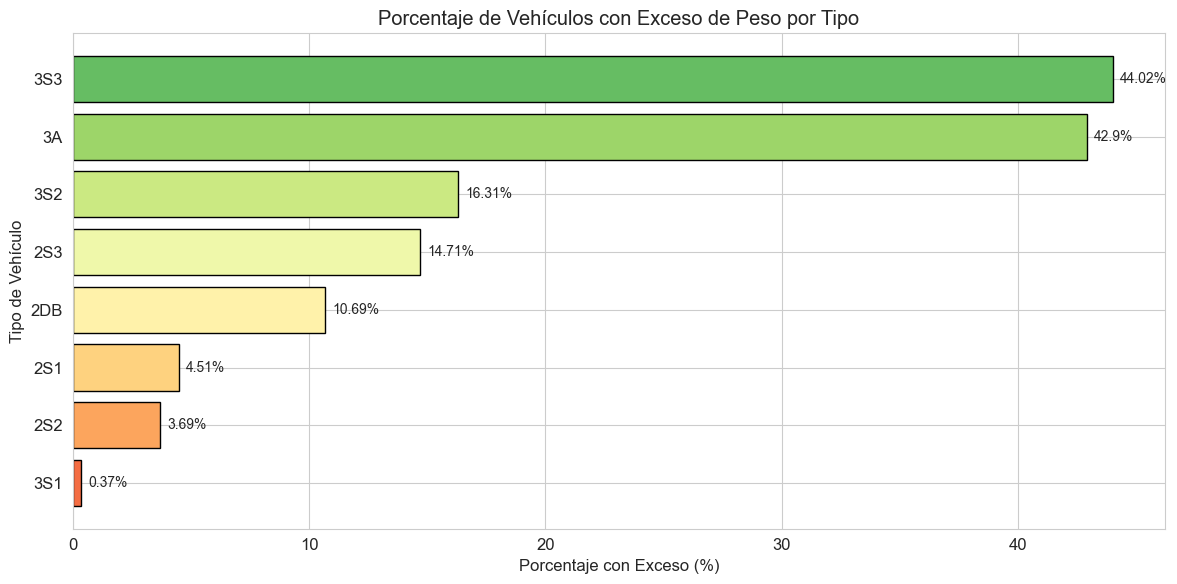

Tipos de vehículo con mayor porcentaje de exceso de peso:
tipo  porcentaje_exceso
 3S3              44.02
  3A              42.90
 3S2              16.31
 2S3              14.71
 2DB              10.69


In [16]:
# ============================================================
# INFRACCIONES POR TIPO DE VEHÍCULO
# Gráfico de barras horizontal que muestra el porcentaje de
# vehículos con exceso de peso para cada tipo de vehículo.
# ============================================================

# Calcular porcentaje de exceso por tipo de vehículo
df_tipo_exceso = df_clean.groupby('tipo').agg(
    total=('TieneExceso', 'count'),
    exceso=('TieneExceso', 'sum')
).reset_index()
df_tipo_exceso['porcentaje_exceso'] = (df_tipo_exceso['exceso'] / df_tipo_exceso['total'] * 100).round(2)
df_tipo_exceso = df_tipo_exceso.sort_values('porcentaje_exceso', ascending=False).head(10)

plt.figure(figsize=(12, 6))
colores_bar = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(df_tipo_exceso)))
plt.barh(df_tipo_exceso['tipo'], df_tipo_exceso['porcentaje_exceso'], color=colores_bar, edgecolor='black')
plt.title('Porcentaje de Vehículos con Exceso de Peso por Tipo')
plt.xlabel('Porcentaje con Exceso (%)')
plt.ylabel('Tipo de Vehículo')
plt.gca().invert_yaxis()

# Agregar etiquetas de valor
for i, v in enumerate(df_tipo_exceso['porcentaje_exceso']):
    plt.text(v + 0.3, i, f'{v}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print('Tipos de vehículo con mayor porcentaje de exceso de peso:')
print(df_tipo_exceso[['tipo', 'porcentaje_exceso']].head(5).to_string(index=False))

## VI. Conclusiones y Recomendaciones

### Conclusiones

1. **Composición del tránsito pesado:** Los tipos de vehículos más comunes en la estación WIM Nobol son los de tipo 2DB (camión de 2 ejes con llanta dual) y 3S3 (camión de 3 ejes con semirremolque de 3 ejes), que representan la mayor parte del tránsito pesado registrado.

2. **Exceso de peso:** Se identificó que un porcentaje de los vehículos circula con exceso de peso, lo que representa un riesgo para la infraestructura vial. Los vehículos con mayor propensión a la sobrecarga son aquellos de mayor capacidad de carga.

3. **Distribución temporal:** El flujo vehicular muestra patrones claros a lo largo del día, con mayor actividad durante las horas de la mañana y la tarde, y una reducción significativa durante la madrugada.

4. **Correlaciones:** Existe una alta correlación entre el peso bruto vehicular y el peso total registrado, lo que valida la consistencia de los datos. El número de ejes está correlacionado con la capacidad de carga del vehículo.

5. **Espectros de carga:** Los datos permiten construir espectros de carga por tipo de eje (sencillo, dual, tandem, tridem), que son fundamentales para el diseño empírico-mecanicista de pavimentos.

### Recomendaciones

1. **Fortalecer los controles de pesaje:** Incrementar la frecuencia de operación de la estación WIM y complementar con pesajes estáticos para reducir la evasión.

2. **Implementar campañas de concienciación:** Educar a transportistas sobre los efectos negativos de la sobrecarga en la infraestructura vial y la seguridad.

3. **Actualizar normativas:** Revisar los límites de carga por eje y peso bruto permitidos, considerando las condiciones actuales de la red vial ecuatoriana.

4. **Monitoreo continuo:** Dar seguimiento mensual a los espectros de carga para detectar cambios en los patrones de tránsito y evaluar la efectividad de las medidas implementadas.

5. **Análisis complementarios:** Realizar estudios adicionales que correlacionen los datos WIM con el deterioro del pavimento en el tramo Nobol para calibrar factores de equivalencia de carga.

## VII. Referencias Bibliográficas

1. Ministerio de Transporte y Obras Públicas del Ecuador (MTOP). (2017). *Informe de Espectros de Carga - Estación WIM Nobol*. Mayo 2017.

2. Instituto Mexicano del Transporte (IMT). *Espectros de Carga para Diseño Empírico-Mecanicista de Pavimentos*.

3. National Cooperative Highway Research Program (NCHRP). (2004). *Report 538: Guide for Mechanistic-Empirical Design of New and Rehabilitated Pavement Structures*. Part 4.

4. McKinney, W. (2017). *Python for Data Analysis: Data Wrangling with Pandas, NumPy, and IPython*. O'Reilly Media.

5. Hunter, J. D. (2007). 'Matplotlib: A 2D Graphics Environment'. *Computing in Science & Engineering*, 9(3), 90-95.

6. Waskom, M. L. (2021). 'Seaborn: Statistical Data Visualization'. *Journal of Open Source Software*, 6(60), 3021.

7. Repositorio del proyecto: [https://github.com/kevinloorf95-glitch/proyectoBP.git](https://github.com/kevinloorf95-glitch/proyectoBP.git)